Title & Description

# Logistic Regression Model - Energy Sector Prediction

This notebook implements a Logistic Regression model to predict the next-day direction of the energy sector (XLE).

## Objective
Predict whether the energy sector will move:
- 1 → Positive (Green)
- 0 → Negative (Red)

## Approach
- Baseline (Naive + Logistic Regression)
- Hyperparameter tuning
- Evaluation (Accuracy, F1, ROC-AUC)
- Sensitivity analysis

Dataset:
- Train: 2016–2023
- Validation: 2024
- Test: 2025

Imports 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)

Load Data

In [16]:
X_train = pd.read_csv("data/X_train(2016-2023).csv", index_col=0)
y_train = pd.read_csv("data/y_train1(2016-2023).csv", index_col=0).values.ravel()

X_val = pd.read_csv("data/X_val(2024).csv", index_col=0)
y_val = pd.read_csv("data/y_val(2024).csv", index_col=0).values.ravel()

X_test = pd.read_csv("data/X_test(2025).csv", index_col=0)
y_test = pd.read_csv("data/y_test(2025).csv", index_col=0).values.ravel()

Evaluation Function

In [17]:
def evaluate_model(y_true, y_pred, y_prob, label=""):
    print(f"\n--- {label} ---")
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)

    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc:.4f}")

    return acc, f1, precision, recall, roc

results_summary = []

Naive Baseline

In [18]:
print("\n--- Naive Baseline (Majority Class) ---")

majority_class = pd.Series(y_train).mode()[0]
baseline_pred = [majority_class] * len(y_test)
baseline_prob = [majority_class] * len(y_test)

acc, f1, precision, recall, roc = evaluate_model(
    y_test, baseline_pred, baseline_prob, "Naive Baseline"
)

results_summary.append(["Naive Baseline", acc, f1, precision, recall, roc])


--- Naive Baseline (Majority Class) ---

--- Naive Baseline ---
Accuracy: 0.5622
F1: 0.7198
Precision: 0.5622
Recall: 1.0000
ROC AUC: 0.5000


Logistic Regression Baseline

In [19]:
print("\nTraining Logistic Regression (Baseline)...")

baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_model.fit(X_train, y_train)

y_test_prob_base = baseline_model.predict_proba(X_test)[:, 1]
y_test_pred_base = (y_test_prob_base >= 0.5).astype(int)

acc, f1, precision, recall, roc = evaluate_model(
    y_test, y_test_pred_base, y_test_prob_base, "LogReg Baseline"
)

results_summary.append(["LogReg Baseline", acc, f1, precision, recall, roc])


Training Logistic Regression (Baseline)...

--- LogReg Baseline ---
Accuracy: 0.5141
F1: 0.5568
Precision: 0.5714
Recall: 0.5429
ROC AUC: 0.5071


Hyperparameter Tuning

In [20]:
print("\n--- Tuning Logistic Regression ---")

C_values = [0.01, 0.1, 1, 10]
best_f1 = 0
best_model = None

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_val_pred)

    print(f"C={C} → Validation F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model = model

print(f"\nBest Validation F1: {best_f1:.4f}")


--- Tuning Logistic Regression ---
C=0.01 → Validation F1=0.5421


C=0.1 → Validation F1=0.5328
C=1 → Validation F1=0.5328
C=10 → Validation F1=0.5328

Best Validation F1: 0.5421


Final Model

In [21]:
print("\n--- Logistic Regression (Tuned) ---")

y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

acc, f1, precision, recall, roc = evaluate_model(
    y_test, y_test_pred, y_test_prob, "LogReg Tuned"
)

results_summary.append(["LogReg Tuned", acc, f1, precision, recall, roc])


--- Logistic Regression (Tuned) ---

--- LogReg Tuned ---
Accuracy: 0.5141
F1: 0.5600
Precision: 0.5704
Recall: 0.5500
ROC AUC: 0.5183


Model Comparison

In [22]:
results_df = pd.DataFrame(
    results_summary,
    columns=["Model", "Accuracy", "F1", "Precision", "Recall", "ROC AUC"]
)

print("\n--- Model Comparison ---")
results_df


--- Model Comparison ---


,Model,Accuracy,F1,Precision,Recall,ROC AUC
0,Naive Baseline,0.562249,0.719794,0.562249,1.000000,0.500000
1,LogReg Baseline,0.514056,0.556777,0.571429,0.542857,0.507143
2,LogReg Tuned,0.514056,0.560000,0.570370,0.550000,0.518349


Confusion Matrix

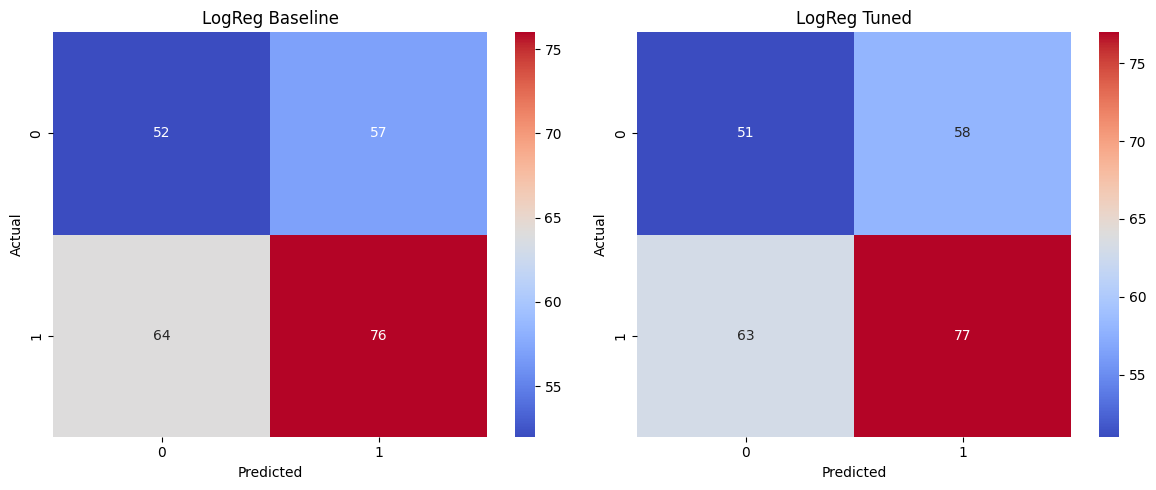

In [23]:
cm_base = confusion_matrix(y_test, y_test_pred_base)
cm_tuned = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
sns.heatmap(cm_base, annot=True, fmt='d', cmap='coolwarm', ax=axes[0])
axes[0].set_title("LogReg Baseline")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Tuned
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='coolwarm', ax=axes[1])
axes[1].set_title("LogReg Tuned")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

ROC Curve

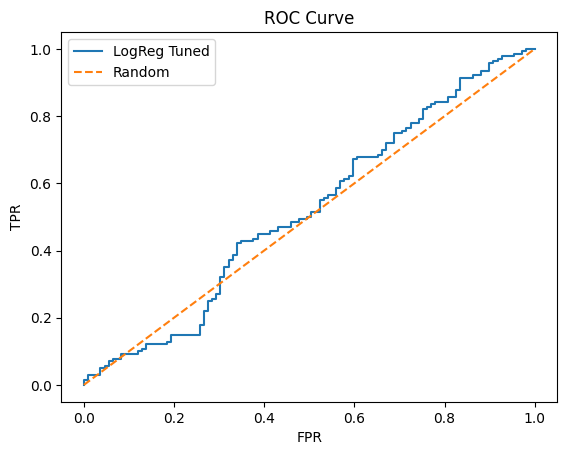

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label="LogReg Tuned")
plt.plot([0, 1], [0, 1], '--', label="Random")
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

Sensitivity Analysis

In [25]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

sens_results = []

for t in thresholds:
    preds = (y_test_prob >= t).astype(int)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)

    sens_results.append([t, acc, f1, precision, recall])

sens_df = pd.DataFrame(
    sens_results,
    columns=["Threshold", "Accuracy", "F1", "Precision", "Recall"]
)

sens_df

,Threshold,Accuracy,F1,Precision,Recall
0,0.3,0.566265,0.718750,0.565574,0.985714
1,0.4,0.582329,0.709497,0.582569,0.907143
2,0.5,0.514056,0.560000,0.570370,0.550000
3,0.6,0.425703,0.192090,0.459459,0.121429
4,0.7,0.449799,0.055172,0.800000,0.028571


Sensitivity Plot

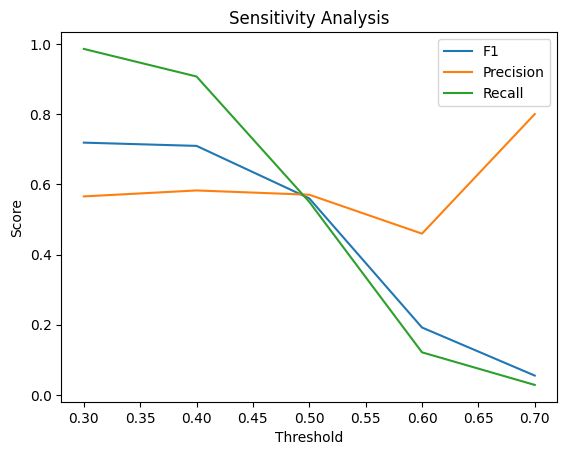

In [26]:
plt.figure()
plt.plot(sens_df["Threshold"], sens_df["F1"], label="F1")
plt.plot(sens_df["Threshold"], sens_df["Precision"], label="Precision")
plt.plot(sens_df["Threshold"], sens_df["Recall"], label="Recall")
plt.title("Sensitivity Analysis")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()